In [14]:
!pip install torch seaborn imblearn

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, classification_report, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# load dataset
columns = [
    'Status', 'Duration', 'CreditHistory', 'Purpose', 'CreditAmount', 'Savings', 'Employment', 'InstallmentRate',
    'PersonalStatusSex', 'Debtors', 'ResidenceSince', 'Property', 'Age', 'OtherInstallmentPlans', 'Housing',
    'ExistingCredits', 'Job', 'NumDependents', 'OwnPhone', 'ForeignWorker', 'Default'
]
df = pd.read_csv('german.data', delim_whitespace=True, header=None, names=columns)

categorical_cols = [
    'Status', 'CreditHistory', 'Purpose', 'Savings', 'Employment',
    'PersonalStatusSex', 'Debtors', 'Property', 'OtherInstallmentPlans',
    'Housing', 'Job', 'OwnPhone', 'ForeignWorker'
]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded['Default'] = df['Default'].map({1: 0, 2: 1})

X = df_encoded.drop('Default', axis=1).values
y = df_encoded['Default'].values

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<ipython-input-16-37cdaddb3ad9>:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('german.data', delim_whitespace=True, header=None, names=columns)


In [17]:
class CreditNet(nn.Module):
    def __init__(self, input_dim):
        super(CreditNet, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.4),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.4),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)


In [19]:
def train(model, criterion, optimizer, loader, device):
    model.train()
    total_loss = 0.0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, device):
    model.eval()
    preds, actual = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs).cpu().numpy().flatten()
            preds.extend(outputs)
            actual.extend(labels.numpy())
    preds_class = (np.array(preds) >= 0.5).astype(int)
    return np.array(actual), preds_class, np.array(preds)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE balancing
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

train_data = TensorDataset(torch.tensor(X_train_res, dtype=torch.float32),
                           torch.tensor(y_train_res, dtype=torch.float32))
test_data = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                          torch.tensor(y_test, dtype=torch.float32))

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CreditNet(X_scaled.shape[1]).to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# train model
epochs = 50
for epoch in range(epochs):
    loss = train(model, criterion, optimizer, train_loader, device)
    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

Epoch 1/50, Loss: 0.6987
Epoch 10/50, Loss: 0.4008
Epoch 20/50, Loss: 0.2952
Epoch 30/50, Loss: 0.2406
Epoch 40/50, Loss: 0.2346
Epoch 50/50, Loss: 0.2054



Classification Report:
               precision    recall  f1-score   support

         0.0     0.8519    0.8214    0.8364       140
         1.0     0.6154    0.6667    0.6400        60

    accuracy                         0.7750       200
   macro avg     0.7336    0.7440    0.7382       200
weighted avg     0.7809    0.7750    0.7775       200



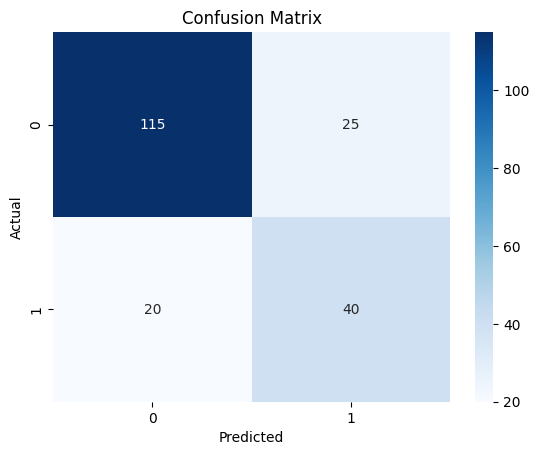

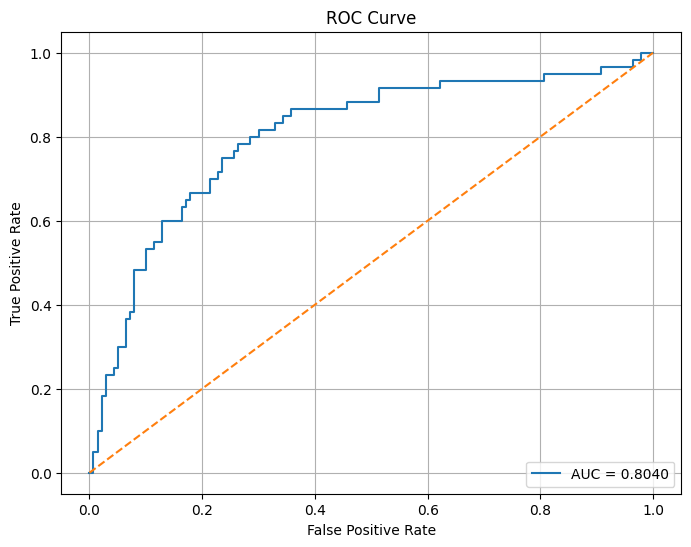

In [21]:
# evaluate model
y_true, y_pred_class, y_pred_prob = evaluate(model, test_loader, device)

print("\nClassification Report:\n", classification_report(y_true, y_pred_class, digits=4))

cm = confusion_matrix(y_true, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC curve and AUC
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = roc_auc_score(y_true, y_pred_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

#Cross-validation

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores, auc_scores = [], []

fold = 1
for train_idx, test_idx in skf.split(X_scaled, y):
    print(f"\nFold {fold}")

    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    train_dataset = TensorDataset(torch.tensor(X_train_res, dtype=torch.float32),
                                  torch.tensor(y_train_res, dtype=torch.float32))
    test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                                 torch.tensor(y_test, dtype=torch.float32))

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)

    model = CreditNet(input_dim=X_scaled.shape[1]).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    epochs = 50
    for epoch in range(epochs):
        loss = train(model, criterion, optimizer, train_loader, device)

    y_true, y_pred_class, y_pred_prob = evaluate(model, test_loader, device)
    report = classification_report(y_true, y_pred_class, digits=4)
    auc = roc_auc_score(y_true, y_pred_prob)
    acc = np.mean(y_true == y_pred_class)

    print(f"Accuracy: {acc:.4f}, AUC: {auc:.4f}")
    print(report)

    accuracy_scores.append(acc)
    auc_scores.append(auc)
    fold += 1

print("\n Cross-validation final results:")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Average AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")


Fold 1
Accuracy: 0.7100, AUC: 0.7011
              precision    recall  f1-score   support

         0.0     0.7770    0.8214    0.7986       140
         1.0     0.5192    0.4500    0.4821        60

    accuracy                         0.7100       200
   macro avg     0.6481    0.6357    0.6404       200
weighted avg     0.6997    0.7100    0.7037       200


Fold 2
Accuracy: 0.7000, AUC: 0.7190
              precision    recall  f1-score   support

         0.0     0.7703    0.8143    0.7917       140
         1.0     0.5000    0.4333    0.4643        60

    accuracy                         0.7000       200
   macro avg     0.6351    0.6238    0.6280       200
weighted avg     0.6892    0.7000    0.6935       200


Fold 3
Accuracy: 0.7150, AUC: 0.7274
              precision    recall  f1-score   support

         0.0     0.8029    0.7857    0.7942       140
         1.0     0.5238    0.5500    0.5366        60

    accuracy                         0.7150       200
   macro avg  